### 중복된 화합물이 많아서 다시 데이터 정리 진행
이전 코드를 다시 살펴보니, skin_irritation_cleaned.csv를 만들 때 분명히 중복 제거를 했음.
그런데도 여전히 동일 구조가 있는 이유???

In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

In [2]:
df = pd.read_csv('skin_irritation_cleaned.csv')
df.shape

(81, 26)

In [3]:
df.columns

Index(['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name',
       'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient',
       'Concentration', 'Concentration_Units', 'Mixture', 'Species',
       'Reported_Strain', 'Strain', 'Sex', 'Assay', 'Endpoint', 'Response',
       'Response_Unit', 'Reference', 'SMILES', 'Preferred_Name', 'Synonyms',
       'URL_CompTox', 'URL_CEBS', 'label'],
      dtype='str')

In [4]:
df['SMILES'].str.contains('.', regex=False)

0     False
1     False
2     False
3      True
4      True
      ...  
76    False
77    False
78    False
79     True
80    False
Name: SMILES, Length: 81, dtype: bool

In [5]:
'''
skin_irritation_cleaned.csv를 준비할 때, 분명히 중복 제거를 했지만 여전히 중복된 화합물이 있는 이유: 화합물 이름을 기준으로 중복 제거를 했기 때문.
아래 테이블을 보면 index 4번과 54번이 동일한 구조를 갖고 있음. 그런데 이름을 보면 4번은 sulphate, 54번은 sulfate로 적혀있음.
화합물 이름으로만 중복 제거를 하면 놓칠 수 있음. 그래서 중복 제거를 할 때는 여러 정보를 기준으로 중복 체크를 진행해야 함.
'''
df.loc[df['SMILES'].str.contains('.', regex=False), ['Chemical_Name','SMILES']]

,Chemical_Name,SMILES
3,di-Propylene glycol,"C*.C*.OCCOCCO |lp:4:2,7:2,10:2,m:1:5.6,3:8.9|"
4,Sodium hydroxide,[OH-].[Na+]
11,Sodium dodecyl sulphate,[Na+].CCCCCCCCCCCCOS([O-])(=O)=O
12,Sodium carbonate,[Na+].[Na+].[O-]C([O-])=O
22,Sodium xylene sulfonate,"C*.C*.OS(=O)(=O)C1=CC=CC=C1 |c:8,10,t:6,lp:4:2..."
24,Sodium percarbonate,[Na+].[Na+].[Na+].[Na+].OO.OO.OO.[O-]C([O-])=O...
48,Ethylenediamine tetraacetic acid disodium salt,[Na+].[Na+].OC(=O)CN(CCN(CC(O)=O)CC([O-])=O)CC...
52,Dipropylene glycol,"C*.C*.OCCOCCO |lp:4:2,7:2,10:2,m:1:5.6,3:8.9|"
57,Sodium dodecyl sulfate,[Na+].CCCCCCCCCCCCOS([O-])(=O)=O
58,Carbonic acid sodium salt (1:2),[Na+].[Na+].[O-]C([O-])=O


In [6]:
#https://docs.chemaxon.com/latest/formats_chemaxon-extended-smiles-and-smarts-cxsmiles-and-cxsmarts.html
#아래 선택된 smiles 코드에 대한 설명 (Notebook LM에 링크 넣고 확인 ㄱㄱ)
df.loc[df['SMILES'].str.contains('|', regex=False), ['Chemical_Name','SMILES']]

,Chemical_Name,SMILES
3,di-Propylene glycol,"C*.C*.OCCOCCO |lp:4:2,7:2,10:2,m:1:5.6,3:8.9|"
22,Sodium xylene sulfonate,"C*.C*.OS(=O)(=O)C1=CC=CC=C1 |c:8,10,t:6,lp:4:2..."
27,Polyethylene glycol 400,"[H]OCCO |lp:1:2,4:2,Sg:n:1,2,3::ht|"
52,Dipropylene glycol,"C*.C*.OCCOCCO |lp:4:2,7:2,10:2,m:1:5.6,3:8.9|"
63,Sodium xylenesulfonate,"C*.C*.OS(=O)(=O)C1=CC=CC=C1 |c:8,10,t:6,lp:4:2..."
65,Polyethylene glycol,"[H]OCCO |lp:1:2,4:2,Sg:n:1,2,3::ht|"


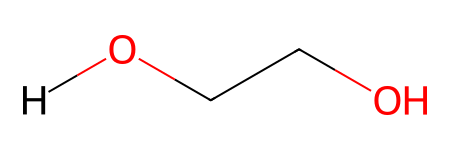

In [7]:
Chem.MolFromSmiles('[H]OCCO |lp:1:2,4:2,Sg:n:1,2,3::ht|')

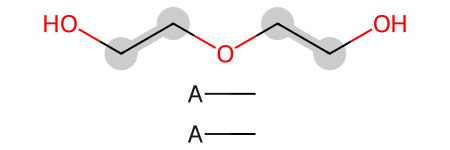

In [8]:
Chem.MolFromSmiles('C*.C*.OCCOCCO |lp:4:2,7:2,10:2,m:1:5.6,3:8.9|')

In [9]:
# | 기호가 있는 화합물은 구조가 명확하지 않아서 제거.
df_clean_smi = df.loc[~df['SMILES'].str.contains('|', regex=False)]

In [10]:
df_clean_smi.loc[df_clean_smi['SMILES'].str.contains('.', regex=False), ['Chemical_Name','SMILES','label']]

,Chemical_Name,SMILES,label
4,Sodium hydroxide,[OH-].[Na+],1
11,Sodium dodecyl sulphate,[Na+].CCCCCCCCCCCCOS([O-])(=O)=O,1
12,Sodium carbonate,[Na+].[Na+].[O-]C([O-])=O,0
24,Sodium percarbonate,[Na+].[Na+].[Na+].[Na+].OO.OO.OO.[O-]C([O-])=O...,0
48,Ethylenediamine tetraacetic acid disodium salt,[Na+].[Na+].OC(=O)CN(CCN(CC(O)=O)CC([O-])=O)CC...,0
57,Sodium dodecyl sulfate,[Na+].CCCCCCCCCCCCOS([O-])(=O)=O,1
58,Carbonic acid sodium salt (1:2),[Na+].[Na+].[O-]C([O-])=O,0
64,"Carbonic acid disodium salt, compd. with hydro...",[Na+].[Na+].[Na+].[Na+].OO.OO.OO.[O-]C([O-])=O...,1
79,"Ethylenediaminetetraacetic acid, disodium salt",[Na+].[Na+].OC(=O)CN(CCN(CC(O)=O)CC([O-])=O)CC...,0


In [11]:
from rdkit.Chem.SaltRemover import SaltRemover

# Initialize with default RDKit salt definitions
remover = SaltRemover()

# Example: Ethanol with a Sodium ion
for index, row in df_clean_smi.iterrows():
    smi = row['SMILES']
    mol = Chem.MolFromSmiles(smi)
    
    if '.' in smi:
        stripped_mol = remover.StripMol(mol) #salt 제거
        stripped_smi = Chem.MolToSmiles(stripped_mol)
        smi_list = stripped_smi.split('.')

        #salt를 제거한 후에도, 분자 구조가 여러개 들어 있음. 가장 큰 분자를 active ingredient로 생각하고 추출. 
        smi_active = ''
        for each_smi in smi_list:
            if len(each_smi) > len(smi_active): #새로운 분자의 smiles 코드가 더 길다면, 더 큰 구조로 판단.
                smi_active = each_smi
        smi_without_salt = smi_active
        
        print (index, smi_without_salt)
    else:
        smi_without_salt = smi

    df_clean_smi.loc[index, 'smi_clean']=smi_without_salt
#4번 인덱스는 smiles 코드가 아무것도 없음. [OH][Na]여서 염제거 과정에서 다 삭제된 것으로 보임.

4 
11 CCCCCCCCCCCCOS(=O)(=O)[O-]
12 O=C([O-])[O-]
24 O=C([O-])[O-]
48 O=C([O-])CN(CCN(CC(=O)[O-])CC(=O)O)CC(=O)O
57 CCCCCCCCCCCCOS(=O)(=O)[O-]
58 O=C([O-])[O-]
64 O=C([O-])[O-]
79 O=C([O-])CN(CCN(CC(=O)[O-])CC(=O)O)CC(=O)O


In [12]:
df_clean_smi

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Concentration,Concentration_Units,...,Response,Response_Unit,Reference,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS,label,smi_clean
0,skin_irritation_invivo_84,In Vivo,NaN,NaN,Propylene glycol,57-55-6,DTXSID0021206,NaN,NaN,NaN,...,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,CC(O)CO,"1,2-Propylene glycol","57-55-6|1,2-Propylene glycol|(.+-.)-1,2-Propan...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0021206,0,CC(O)CO
1,skin_irritation_invivo_12,In Vivo,NaN,NaN,Heptanal,111-71-7,DTXSID0021597,NaN,NaN,NaN,...,Irritant,Unitless,Jirova et al. 2010; 20136894; 10.1111/j.1600-0...,CCCCCCC=O,Heptanal,111-71-7|Heptanal|1-Heptaldehyde|1-Heptanal|Al...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0021597,1,CCCCCCC=O
2,skin_irritation_invivo_33,In Vivo,NaN,NaN,Isopropyl myristate,110-27-0,DTXSID0026838,NaN,NaN,NaN,...,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,CCCCCCCCCCCCCC(=O)OC(C)C,Isopropyl tetradecanoate,110-27-0|Isopropyl tetradecanoate|1-Methylethy...,https://comptox.epa.gov/dashboard/chemical/det...,NaN,0,CCCCCCCCCCCCCC(=O)OC(C)C
4,skin_irritation_invivo_63,In Vivo,NaN,NaN,Sodium hydroxide,1310-73-2,DTXSID0029634,NaN,NaN,NaN,...,Irritant/Possible corrosive,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,[OH-].[Na+],Sodium hydroxide,1310-73-2|Sodium hydroxide|Aetznatron|ANHYDROU...,https://comptox.epa.gov/dashboard/chemical/det...,NaN,1,
5,skin_irritation_invivo_51,In Vivo,NaN,NaN,4-Methylthio benzaldehyde,3446-89-7,DTXSID0033047,NaN,NaN,NaN,...,Not classified,Unitless,Jirova et al. 2010; 20136894; 10.1111/j.1600-0...,CSC1=CC=C(C=O)C=C1,4-(Methylthio)benzaldehyde,3446-89-7|4-(Methylthio)benzaldehyde|Benzaldeh...,https://comptox.epa.gov/dashboard/chemical/det...,NaN,0,CSC1=CC=C(C=O)C=C1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,skin_irritation_invivo_30,In Vivo,NaN,NaN,"Hexane, 3,3-bis(methoxymethyl)-2,5-dimethyl-",129228-21-3,DTXSID80456581,NaN,NaN,NaN,...,20.7,%,Jirova et al. 2010; 20136894; 10.1111/j.1600-0...,COCC(COC)(CC(C)C)C(C)C,"Hexane, 3,3-bis(methoxymethyl)-2,5-dimethyl-","129228-21-3|Hexane, 3,3-bis(methoxymethyl)-2,5...",https://comptox.epa.gov/dashboard/chemical/det...,NaN,1,COCC(COC)(CC(C)C)C(C)C
77,skin_irritation_invivo_72,In Vivo,NaN,NaN,1-Spiro[4.5]dec-7-en-7-yl-4-penten-1-one,224031-70-3,DTXSID80870263,NaN,NaN,NaN,...,0,%,Jirova et al. 2010; 20136894; 10.1111/j.1600-0...,C=CCCC(=O)C1=CCCC2(CCCC2)C1,1-Spiro[4.5]dec-7-en-7-yl-4-penten-1-one,224031-70-3|1-Spiro[4.5]dec-7-en-7-yl-4-penten...,https://comptox.epa.gov/dashboard/chemical/det...,NaN,0,C=CCCC(=O)C1=CCCC2(CCCC2)C1
78,skin_irritation_invivo_76,In Vivo,NaN,NaN,1-Tetradecanol,112-72-1,DTXSID9026926,NaN,NaN,NaN,...,0,%,Basketter et al. 2004; 15291823; 10.1111/j.010...,CCCCCCCCCCCCCCO,1-Tetradecanol,112-72-1|1-Tetradecanol|1-Hydroxytetradecane|1...,https://comptox.epa.gov/dashboard/chemical/det...,NaN,0,CCCCCCCCCCCCCCO
79,skin_irritation_invivo_8,In Vivo,NaN,NaN,"Ethylenediaminetetraacetic acid, disodium salt",139-33-3,DTXSID9027073,NaN,NaN,NaN,...,0,%,Basketter et al. 2004; 15291823; 10.1111/j.010...,[Na+].[Na+].OC(=O)CN(CCN(CC(O)=O)CC([O-])=O)CC...,"Ethylenediaminetetraacetic acid, disodium salt","139-33-3|Ethylenediaminetetraacetic acid, diso...",https://comptox.epa.gov/dashboard/chemical/det...,NaN,0,O=C([O-])CN(CCN(CC(=O)[O-])CC(=O)O)CC(=O)O


In [13]:
#smiles 표준화
for index, row in df_clean_smi.iterrows():
    smi = row['smi_clean']
    mol = Chem.MolFromSmiles(smi)
    smi_standard = Chem.MolToSmiles(mol)
    df_clean_smi.loc[index, 'standardized_smi'] = smi_standard


In [14]:
df_clean_smi[['Chemical_Name','standardized_smi','label']]

,Chemical_Name,standardized_smi,label
0,Propylene glycol,CC(O)CO,0
1,Heptanal,CCCCCCC=O,1
2,Isopropyl myristate,CCCCCCCCCCCCCC(=O)OC(C)C,0
4,Sodium hydroxide,,1
5,4-Methylthio benzaldehyde,CSc1ccc(C=O)cc1,0
...,...,...,...
76,"Hexane, 3,3-bis(methoxymethyl)-2,5-dimethyl-",COCC(COC)(CC(C)C)C(C)C,1
77,1-Spiro[4.5]dec-7-en-7-yl-4-penten-1-one,C=CCCC(=O)C1=CCCC2(CCCC2)C1,0
78,1-Tetradecanol,CCCCCCCCCCCCCCO,0
79,"Ethylenediaminetetraacetic acid, disodium salt",O=C([O-])CN(CCN(CC(=O)[O-])CC(=O)O)CC(=O)O,0


In [15]:
unique_smi = set(df_clean_smi['standardized_smi'].to_list())
len(unique_smi)

48

In [16]:
unique_smi.remove('') #smiles 코드 중 ''이 보여서 제거.

In [17]:
len(unique_smi)

47

In [18]:
for smi in unique_smi:
    print (smi)

CS(C)=O
CC1=CCC(C(C)(C)O)CC1
CCCCCCCCCCCCCC(=O)O
CC(C)=CCCC(C)=CCO
CC(O)CO
CCCCCCCC(=O)O
CCCCCCO
CC(O)C(=O)O
CC(=O)OC(C)(C)C1CC=C(C)CC1
O=C([O-])CN(CCN(CC(=O)[O-])CC(=O)O)CC(=O)O
CCCCCCC=O
COCC(COC)(CC(C)C)C(C)C
Cc1c[nH]nc1C
CCCCCCCCCCCCCCCC(=O)OC(C)C
CCCCCCCCCCCCCC(=O)OC(C)C
O=C(O)Cc1cccc2ccccc12
COC(=O)c1ccccc1N=CCC(C)CCCC(C)(C)O
CCCCCCCCCCCCO
CC(O)COC(C)(C)C
CCCCCCCCCCCCCCO
C=C(C)C(=O)OCCCC
CCCCCCCCCCO
CCCCCCCCC(=O)O
CCCCCCOC(=O)c1ccccc1O
CCCCCO
C=CCCC(=O)C1=CCCC2(CCCC2)C1
CC(C)O
CCCCCCCOC(=O)CCC
O=C(OCc1ccccc1)c1ccccc1O
CCCSSCCC
ClCCCCBr
CCCCCCCCO
O=C([O-])[O-]
CCCCCCCCCCCC(=O)OC
NC(CO)(CO)CO
CCCCCCCCCCCCCCCC(=O)O
CCCCCCCCCCCCCCCC(=O)OC
OCCN(CCO)CCO
CC(C)=CCCC(C)CCO
CCCCOC(=O)c1ccccc1
CCCCCC(=O)OC
CCCCCCCCCCCCOS(=O)(=O)[O-]
CSc1ccc(C=O)cc1
CCCCCCCCCC(=O)O
CCCCCCC(=O)O
CC(C)c1ccccc1C(C)c1ccccc1
CCCCCCBr


In [19]:
df_clean_smi.groupby('standardized_smi')['label'].nunique()

standardized_smi
                                              1
C=C(C)C(=O)OCCCC                              1
C=CCCC(=O)C1=CCCC2(CCCC2)C1                   1
CC(=O)OC(C)(C)C1CC=C(C)CC1                    1
CC(C)=CCCC(C)=CCO                             2
CC(C)=CCCC(C)CCO                              1
CC(C)O                                        1
CC(C)c1ccccc1C(C)c1ccccc1                     1
CC(O)C(=O)O                                   1
CC(O)CO                                       2
CC(O)COC(C)(C)C                               1
CC1=CCC(C(C)(C)O)CC1                          1
CCCCCC(=O)OC                                  1
CCCCCCBr                                      1
CCCCCCC(=O)O                                  1
CCCCCCC=O                                     1
CCCCCCCC(=O)O                                 1
CCCCCCCCC(=O)O                                1
CCCCCCCCCC(=O)O                               1
CCCCCCCCCCCC(=O)OC                            1
CCCCCCCCCCCCCC(=O)O    

In [20]:
df_filtered = df_clean_smi.groupby('standardized_smi').filter(lambda x: x['label'].nunique() == 1)

In [21]:
df_filtered.groupby('standardized_smi')['label'].nunique()

standardized_smi
                                              1
C=C(C)C(=O)OCCCC                              1
C=CCCC(=O)C1=CCCC2(CCCC2)C1                   1
CC(=O)OC(C)(C)C1CC=C(C)CC1                    1
CC(C)=CCCC(C)CCO                              1
CC(C)O                                        1
CC(C)c1ccccc1C(C)c1ccccc1                     1
CC(O)C(=O)O                                   1
CC(O)COC(C)(C)C                               1
CC1=CCC(C(C)(C)O)CC1                          1
CCCCCC(=O)OC                                  1
CCCCCCBr                                      1
CCCCCCC(=O)O                                  1
CCCCCCC=O                                     1
CCCCCCCC(=O)O                                 1
CCCCCCCCC(=O)O                                1
CCCCCCCCCC(=O)O                               1
CCCCCCCCCCCC(=O)OC                            1
CCCCCCCCCCCCCC(=O)O                           1
CCCCCCCCCCCCCCCC(=O)O                         1
CCCCCCCCCCCCCCCC(=O)OC(

In [22]:
df_filtered.groupby('standardized_smi')['label'].nunique().shape

(40,)

In [23]:
df_filtered.shape

(57, 28)

In [24]:
df_unique = df_filtered.drop_duplicates(subset='standardized_smi')

In [25]:
df_unique.shape

(40, 28)

In [26]:
df_unique['label'].value_counts()

label
0    26
1    14
Name: count, dtype: int64

In [27]:
desc_total = []
for index, row in df_unique.iterrows():
    smi = row['SMILES']
    mol = Chem.MolFromSmiles(smi)
    desc = Descriptors.CalcMolDescriptors(mol)
    desc_total.append(desc)

In [28]:
df_desc = pd.DataFrame(desc_total)

In [29]:
df_desc

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,9.768009,9.768009,0.750000,0.750000,0.395123,9.125000,114.188,100.076,114.104465,48,...,0,0,0,0,0,0,0,0,4,0
1,0.000000,0.000000,0.000000,0.000000,0.262038,0.000000,39.997,38.989,39.992509,8,...,0,0,0,0,0,0,0,0,0,0
2,10.199308,10.199308,0.734074,0.734074,0.477177,9.300000,152.218,144.154,152.029586,52,...,1,0,0,0,0,0,0,0,0,0
3,10.909695,10.909695,0.043526,-0.043526,0.429221,10.000000,186.295,164.119,186.161980,78,...,0,0,0,0,0,0,0,0,4,0
4,11.646816,11.646816,0.369467,-0.590016,0.579721,13.318182,305.418,278.202,305.199094,122,...,0,0,0,0,0,0,0,0,0,0
5,10.464402,10.464402,0.094028,-0.094028,0.427720,9.111111,130.187,116.075,130.099380,54,...,0,0,0,0,0,0,0,0,2,0
6,2.288241,2.288241,0.467407,0.467407,0.690772,12.705882,224.347,204.187,224.156501,88,...,0,0,0,0,0,0,0,0,0,0
7,11.656605,11.656605,0.064295,-0.521340,0.821476,9.882353,228.247,216.151,228.078644,86,...,0,0,0,0,0,0,0,0,0,0
8,10.113810,10.113810,0.000000,-4.484382,0.225415,11.222222,288.385,263.185,288.137125,104,...,0,0,0,0,0,0,0,0,9,0
9,5.359460,5.359460,0.797222,0.797222,0.451849,9.000000,171.465,163.401,169.949790,38,...,0,0,0,0,0,0,0,0,1,0


In [30]:
df_id = df_unique[['Chemical_Name','standardized_smi','label']]

In [31]:
df_id #중간에 subset 하면서 index값이 1 다음 4로 건너뛰는 것을 확인.

,Chemical_Name,standardized_smi,label
1,Heptanal,CCCCCCC=O,1
4,Sodium hydroxide,,1
5,4-Methylthio benzaldehyde,CSc1ccc(C=O)cc1,0
6,Heptyl butyrate,CCCCCCCOC(=O)CCC,0
7,Hydroxycitronellal,COC(=O)c1ccccc1N=CCC(C)CCCC(C)(C)O,0
8,Methyl caproate,CCCCCC(=O)OC,0
9,1-(2-Isopropylphenyl)-1-phenyle- thane (Mixtur...,CC(C)c1ccccc1C(C)c1ccccc1,0
10,Benzyl salicylate,O=C(OCc1ccccc1)c1ccccc1O,0
11,Sodium dodecyl sulphate,CCCCCCCCCCCCOS(=O)(=O)[O-],1
13,1-Bromo-4-chlorobutane,ClCCCCBr,0


In [32]:
df_final = pd.concat([df_id,df_desc],axis=1)

In [33]:
df_final #concatenation 실패. row가 40개가 나와야 하는데 51개. (df_id와 df_desc의 index 번호가 일치하지 않기 때문)

,Chemical_Name,standardized_smi,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
1,Heptanal,CCCCCCC=O,1.0,0.000000,0.000000,0.000000,0.000000,0.262038,0.000000,39.997,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Sodium hydroxide,,1.0,11.646816,11.646816,0.369467,-0.590016,0.579721,13.318182,305.418,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4-Methylthio benzaldehyde,CSc1ccc(C=O)cc1,0.0,10.464402,10.464402,0.094028,-0.094028,0.427720,9.111111,130.187,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
6,Heptyl butyrate,CCCCCCCOC(=O)CCC,0.0,2.288241,2.288241,0.467407,0.467407,0.690772,12.705882,224.347,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Hydroxycitronellal,COC(=O)c1ccccc1N=CCC(C)CCCC(C)(C)O,0.0,11.656605,11.656605,0.064295,-0.521340,0.821476,9.882353,228.247,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Methyl caproate,CCCCCC(=O)OC,0.0,10.113810,10.113810,0.000000,-4.484382,0.225415,11.222222,288.385,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0
9,1-(2-Isopropylphenyl)-1-phenyle- thane (Mixtur...,CC(C)c1ccccc1C(C)c1ccccc1,0.0,5.359460,5.359460,0.797222,0.797222,0.451849,9.000000,171.465,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10,Benzyl salicylate,O=C(OCc1ccccc1)c1ccccc1O,0.0,9.962453,9.962453,0.333333,-0.674905,0.578065,9.444444,130.187,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
11,Sodium dodecyl sulphate,CCCCCCCCCCCCOS(=O)(=O)[O-],1.0,10.300651,10.300651,0.345000,-0.654562,0.413490,10.722222,256.430,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0
13,1-Bromo-4-chlorobutane,ClCCCCBr,0.0,10.928722,10.928722,0.179375,-0.316435,0.500892,22.857143,196.290,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
df_id.reset_index()

,index,Chemical_Name,standardized_smi,label
0,1,Heptanal,CCCCCCC=O,1
1,4,Sodium hydroxide,,1
2,5,4-Methylthio benzaldehyde,CSc1ccc(C=O)cc1,0
3,6,Heptyl butyrate,CCCCCCCOC(=O)CCC,0
4,7,Hydroxycitronellal,COC(=O)c1ccccc1N=CCC(C)CCCC(C)(C)O,0
5,8,Methyl caproate,CCCCCC(=O)OC,0
6,9,1-(2-Isopropylphenyl)-1-phenyle- thane (Mixtur...,CC(C)c1ccccc1C(C)c1ccccc1,0
7,10,Benzyl salicylate,O=C(OCc1ccccc1)c1ccccc1O,0
8,11,Sodium dodecyl sulphate,CCCCCCCCCCCCOS(=O)(=O)[O-],1
9,13,1-Bromo-4-chlorobutane,ClCCCCBr,0


In [35]:
df_id.reset_index(drop=True)

,Chemical_Name,standardized_smi,label
0,Heptanal,CCCCCCC=O,1
1,Sodium hydroxide,,1
2,4-Methylthio benzaldehyde,CSc1ccc(C=O)cc1,0
3,Heptyl butyrate,CCCCCCCOC(=O)CCC,0
4,Hydroxycitronellal,COC(=O)c1ccccc1N=CCC(C)CCCC(C)(C)O,0
5,Methyl caproate,CCCCCC(=O)OC,0
6,1-(2-Isopropylphenyl)-1-phenyle- thane (Mixtur...,CC(C)c1ccccc1C(C)c1ccccc1,0
7,Benzyl salicylate,O=C(OCc1ccccc1)c1ccccc1O,0
8,Sodium dodecyl sulphate,CCCCCCCCCCCCOS(=O)(=O)[O-],1
9,1-Bromo-4-chlorobutane,ClCCCCBr,0


In [36]:
df_final = pd.concat([df_id.reset_index(drop=True),df_desc],axis=1)

In [37]:
df_final #concatenation 성공 (row 개수 40개)

,Chemical_Name,standardized_smi,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,Heptanal,CCCCCCC=O,1,9.768009,9.768009,0.750000,0.750000,0.395123,9.125000,114.188,...,0,0,0,0,0,0,0,0,4,0
1,Sodium hydroxide,,1,0.000000,0.000000,0.000000,0.000000,0.262038,0.000000,39.997,...,0,0,0,0,0,0,0,0,0,0
2,4-Methylthio benzaldehyde,CSc1ccc(C=O)cc1,0,10.199308,10.199308,0.734074,0.734074,0.477177,9.300000,152.218,...,1,0,0,0,0,0,0,0,0,0
3,Heptyl butyrate,CCCCCCCOC(=O)CCC,0,10.909695,10.909695,0.043526,-0.043526,0.429221,10.000000,186.295,...,0,0,0,0,0,0,0,0,4,0
4,Hydroxycitronellal,COC(=O)c1ccccc1N=CCC(C)CCCC(C)(C)O,0,11.646816,11.646816,0.369467,-0.590016,0.579721,13.318182,305.418,...,0,0,0,0,0,0,0,0,0,0
5,Methyl caproate,CCCCCC(=O)OC,0,10.464402,10.464402,0.094028,-0.094028,0.427720,9.111111,130.187,...,0,0,0,0,0,0,0,0,2,0
6,1-(2-Isopropylphenyl)-1-phenyle- thane (Mixtur...,CC(C)c1ccccc1C(C)c1ccccc1,0,2.288241,2.288241,0.467407,0.467407,0.690772,12.705882,224.347,...,0,0,0,0,0,0,0,0,0,0
7,Benzyl salicylate,O=C(OCc1ccccc1)c1ccccc1O,0,11.656605,11.656605,0.064295,-0.521340,0.821476,9.882353,228.247,...,0,0,0,0,0,0,0,0,0,0
8,Sodium dodecyl sulphate,CCCCCCCCCCCCOS(=O)(=O)[O-],1,10.113810,10.113810,0.000000,-4.484382,0.225415,11.222222,288.385,...,0,0,0,0,0,0,0,0,9,0
9,1-Bromo-4-chlorobutane,ClCCCCBr,0,5.359460,5.359460,0.797222,0.797222,0.451849,9.000000,171.465,...,0,0,0,0,0,0,0,0,1,0


In [38]:
#https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
#logistic regression 모델 만들어보기

from sklearn.linear_model import LogisticRegression

y = df_final['label']
x = df_final.drop(columns=['Chemical_Name','standardized_smi','label'])

In [39]:
y

0     1
1     1
2     0
3     0
4     0
5     0
6     0
7     0
8     1
9     0
10    1
11    0
12    1
13    0
14    1
15    1
16    0
17    1
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    1
27    0
28    0
29    0
30    1
31    0
32    1
33    0
34    1
35    0
36    0
37    0
38    1
39    1
Name: label, dtype: int64

In [40]:
x

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,9.768009,9.768009,0.750000,0.750000,0.395123,9.125000,114.188,100.076,114.104465,48,...,0,0,0,0,0,0,0,0,4,0
1,0.000000,0.000000,0.000000,0.000000,0.262038,0.000000,39.997,38.989,39.992509,8,...,0,0,0,0,0,0,0,0,0,0
2,10.199308,10.199308,0.734074,0.734074,0.477177,9.300000,152.218,144.154,152.029586,52,...,1,0,0,0,0,0,0,0,0,0
3,10.909695,10.909695,0.043526,-0.043526,0.429221,10.000000,186.295,164.119,186.161980,78,...,0,0,0,0,0,0,0,0,4,0
4,11.646816,11.646816,0.369467,-0.590016,0.579721,13.318182,305.418,278.202,305.199094,122,...,0,0,0,0,0,0,0,0,0,0
5,10.464402,10.464402,0.094028,-0.094028,0.427720,9.111111,130.187,116.075,130.099380,54,...,0,0,0,0,0,0,0,0,2,0
6,2.288241,2.288241,0.467407,0.467407,0.690772,12.705882,224.347,204.187,224.156501,88,...,0,0,0,0,0,0,0,0,0,0
7,11.656605,11.656605,0.064295,-0.521340,0.821476,9.882353,228.247,216.151,228.078644,86,...,0,0,0,0,0,0,0,0,0,0
8,10.113810,10.113810,0.000000,-4.484382,0.225415,11.222222,288.385,263.185,288.137125,104,...,0,0,0,0,0,0,0,0,9,0
9,5.359460,5.359460,0.797222,0.797222,0.451849,9.000000,171.465,163.401,169.949790,38,...,0,0,0,0,0,0,0,0,1,0


In [41]:
clf = LogisticRegression()

In [42]:
clf.fit(x,y) #학습 실패. descriptor 계산 값중에 NaN이 섞여 있기 때문.

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# NaN이 발생한 값은 descriptor 계산에 실패했기 때문.
# 현재 화합물 개수(row)가 너무 적기 때문에, NaN이 있는 column을 제거한 후 모델 학습 진행 필요.
# Task: NaN이 포함되어 있는 컬럼 찾은 후, clf.fit(x,y)으로 모델 학습하기.
# 학습에 성공하면, clf.score(x, y)를 통해 모델의 정확도를 계산할 수 있음. 모델 정확도 확인해보기.
'''
모델 학습에 성공한 사람은 다른 fingerprint를 x로 준비해서 모델 개발해보기. 어떤 feature에서 가장 성능이 높게 나올까?
descriptor와 fingerprint 종류 별로 따로따로 모델 훈련하기.
'''